### Seasonal Agriculture Performance Analysis

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [2]:
df = pd.read_csv("C:\my projects\seasonal_agriculture_performance project\seasonal_agriculture_performance_dataset (1).csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

### Data Cleaning and preparation

In [4]:
# missing values
df.isnull().sum()[df.isnull().sum() > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [5]:
#  duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values remain
df.isnull().sum().sum()


np.int64(0)

In [7]:
#  statistical summary of numeric columns
df.describe().round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,...,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,600.92,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,...,0.83,5.24,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,287.19,3.82,11.96,1.12,0.64,6.68,31.22,17.02,27.74,...,0.10,13.31,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,...,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,371.58,23.90,54.78,6.60,6.26,21.80,98.50,46.20,86.20,...,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,...,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,831.98,29.60,71.90,8.10,7.14,31.20,141.22,69.40,123.60,...,0.91,2.83,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,...,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


###  Seasonal Overview

farm records belong to each season and Distribution of Crops

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


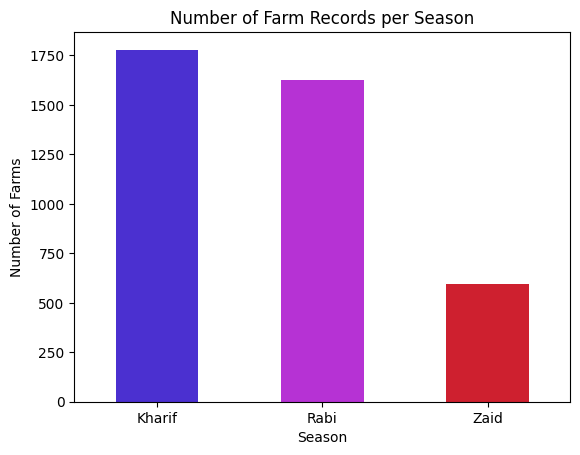

In [8]:
season_counts = df['Season'].value_counts()
print(season_counts)

season_counts.plot(kind='bar', color=["#4B30D0", "#B632D4", "#CE202F"])
plt.title("Number of Farm Records per Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.show()


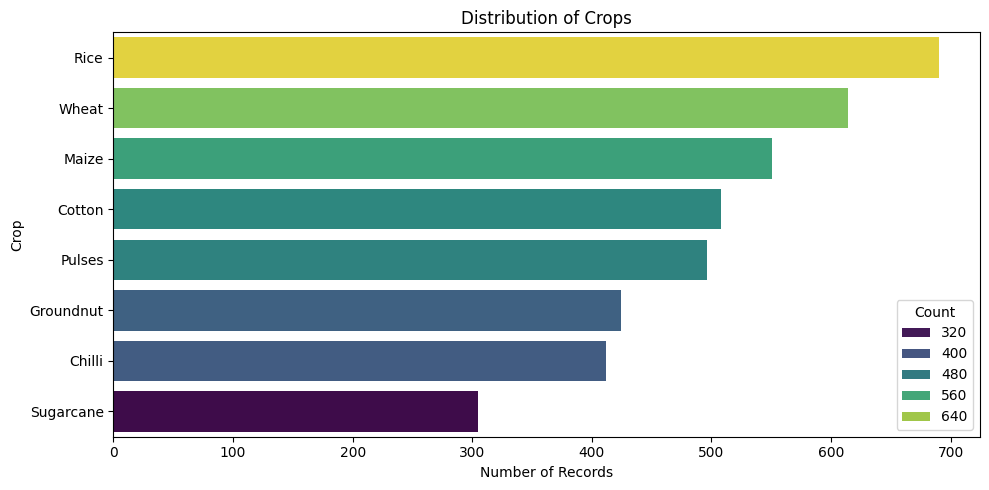

In [9]:
plt.figure(figsize=(10, 5))

crop_count = df["Crop"].value_counts().reset_index()
crop_count.columns = ["Crop", "Count"]

sns.barplot(data=crop_count, y="Crop", x="Count",hue = 'Count',palette='viridis')

plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

### 4. Average Yield by Season

Season
Kharif    5.63
Rabi      5.04
Zaid      4.64
Name: Yield_Tonnes_Ha, dtype: float64


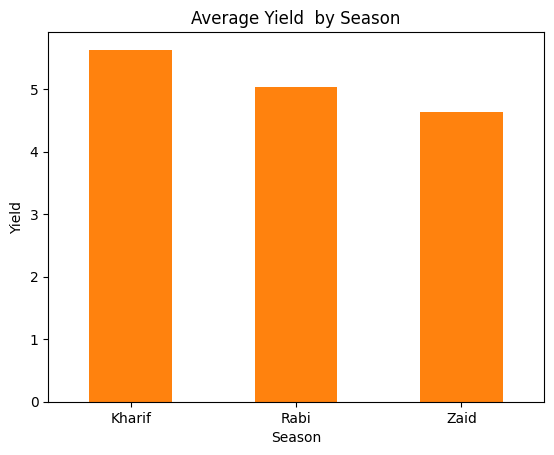

In [10]:
avg_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().round(2)
print(avg_yield)

avg_yield.plot(kind='bar', color="#FF820E")
plt.title("Average Yield  by Season")
plt.ylabel("Yield")
plt.xticks(rotation=0)
plt.show()


### 5. Average Profit by Season

Season
Kharif    178915.0
Rabi       87689.0
Zaid      -24805.0
Name: Profit_INR, dtype: float64


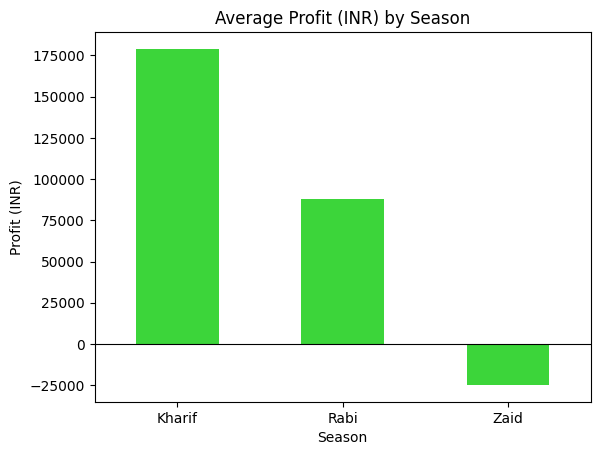

In [11]:
avg_profit = df.groupby('Season')['Profit_INR'].mean().round(0)
print(avg_profit)

avg_profit.plot(kind='bar', color="#3CD53A")
plt.title("Average Profit (INR) by Season")
plt.ylabel("Profit (INR)")
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.show()


### 6. Percentage of Farms Operating at a Loss, by Season

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Made_Loss, dtype: float64


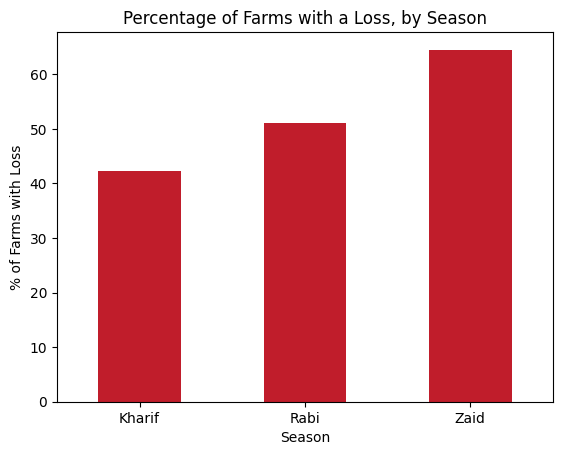

In [12]:
df['Made_Loss'] = df['Profit_INR'] < 0
loss_pct = (df.groupby('Season')['Made_Loss'].mean() * 100).round(1)
print(loss_pct)

loss_pct.plot(kind='bar', color="#C01D2B")
plt.title("Percentage of Farms with a Loss, by Season")
plt.ylabel("% of Farms with Loss")
plt.xticks(rotation=0)
plt.show()


## Environmental Conditions across Seasons

### Rainfall Season

Season
Kharif    849.2
Rabi      437.6
Zaid      304.7
Name: Rainfall_mm, dtype: float64


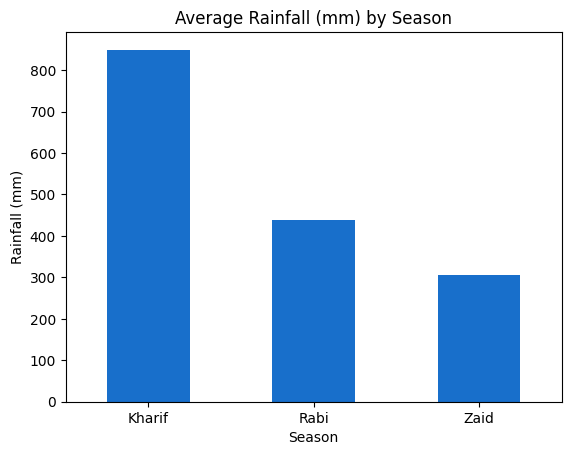

In [13]:
avg_rainfall = df.groupby('Season')['Rainfall_mm'].mean().round(1)
print(avg_rainfall)

avg_rainfall.plot(kind='bar', color="#186FCB")
plt.title("Average Rainfall (mm) by Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=0)
plt.show()


### Average Temperature season

Season
Kharif    28.5
Rabi      23.5
Zaid      31.0
Name: Avg_Temperature_C, dtype: float64


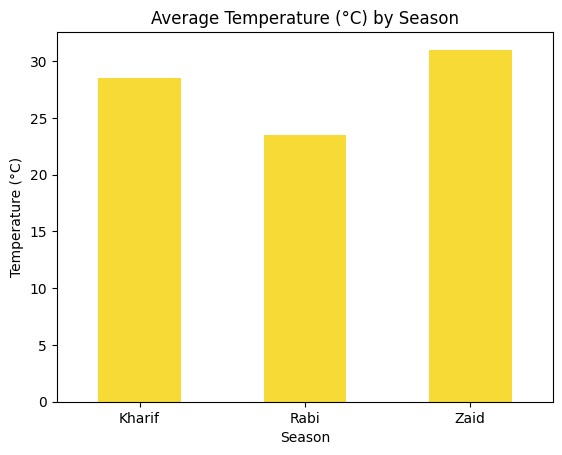

In [14]:
avg_temp = df.groupby('Season')['Avg_Temperature_C'].mean().round(1)
print(avg_temp)

avg_temp.plot(kind='bar', color="#F7DA35")
plt.title("Average Temperature (°C) by Season")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=0)
plt.show()


**Observation:** Kharif is the wettest and moderately warm season, Rabi is the coolest and driest, and Zaid is the hottest season with the least rainfall. These conditions largely explain the yield and profit patterns seen above.

### Water Usage and Water Efficiency across Seasons

        Water_Used_m3  Water_Efficiency_t_per_1000m3
Season                                              
Kharif        6102.20                           5.89
Rabi          5846.99                           5.19
Zaid          6419.89                           4.41


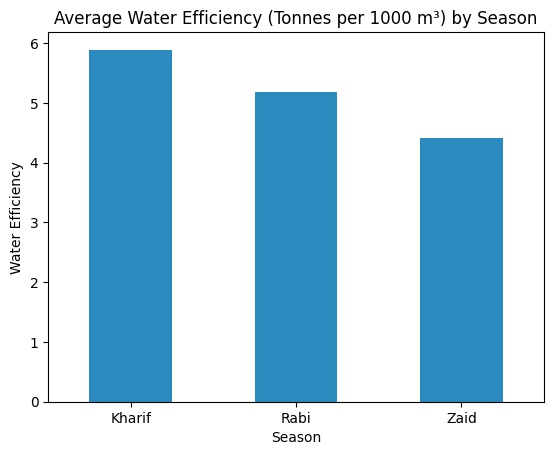

In [15]:
water = df.groupby('Season')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().round(2)
print(water)

water['Water_Efficiency_t_per_1000m3'].sort_values(ascending=False).plot(kind='bar', color="#2B8BBF")
plt.title("Average Water Efficiency (Tonnes per 1000 m³) by Season")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=0)
plt.show()


**Observation:** Zaid uses more water on average but has the lowest water efficiency, while Kharif achieves the best output per unit of water used.

### 12. Effect of Irrigation Method on Yield

Irrigation_Method
Drip         6.58
Sprinkler    5.16
Flood        4.86
Rainfed      4.60
Name: Yield_Tonnes_Ha, dtype: float64


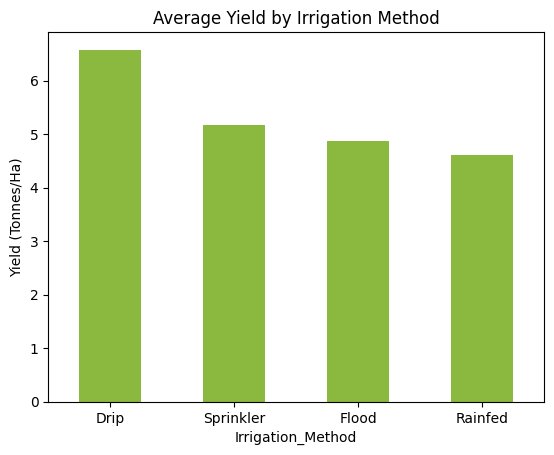

In [16]:
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
print(irrigation_yield.round(2))

irrigation_yield.plot(kind='bar', color="#8BB940")
plt.title("Average Yield by Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()


Drip irrigation gives the best yield, while Rainfed gives the lowest. Irrigation method makes a clear difference.

### 10. Disease and Pest Risk by Season

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


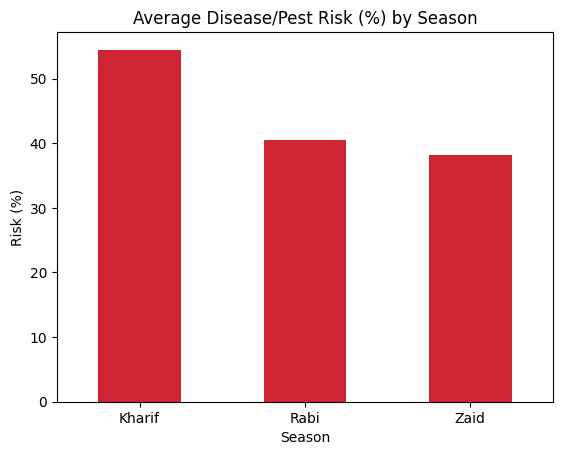

In [17]:
avg_risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False).round(2)
print(avg_risk)

avg_risk.plot(kind='bar', color="#CE2533")
plt.title("Average Disease/Pest Risk (%) by Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.show()


Kharif has the highest disease/pest risk, likely because of higher rainfall and humidity — so even though it's the best-performing season, it also needs the most careful pest management.

### Which Crop–Season Combinations are Most and Least Profitable?

In [18]:
crop_season_profit = df.groupby(['Crop', 'Season'])['Profit_INR'].mean().round(0)

print("Top 5 most profitable Crop-Season combinations:")
print(crop_season_profit.sort_values(ascending=False).head(5))

print("\nTop 5 least profitable Crop-Season combinations:")
print(crop_season_profit.sort_values().head(5))


Top 5 most profitable Crop-Season combinations:
Crop       Season
Sugarcane  Kharif    1000791.0
Chilli     Kharif     954380.0
Sugarcane  Rabi       731613.0
Chilli     Rabi       638572.0
Sugarcane  Zaid       583636.0
Name: Profit_INR, dtype: float64

Top 5 least profitable Crop-Season combinations:
Crop    Season
Rice    Zaid     -227239.0
Maize   Zaid     -194049.0
Wheat   Zaid     -193209.0
Pulses  Zaid     -139228.0
Wheat   Rabi     -119955.0
Name: Profit_INR, dtype: float64


In [19]:
# Pivot table: average profit for each crop across seasons
profit_pivot = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean').round(0)
profit_pivot


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


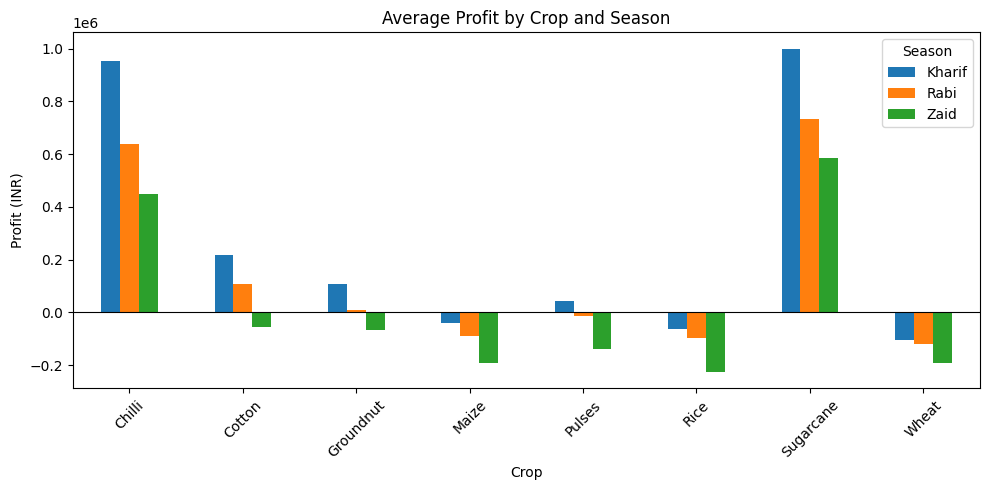

In [20]:
profit_pivot.plot(kind='bar', figsize=(10, 5))
plt.title("Average Profit by Crop and Season")
plt.ylabel("Profit (INR)")
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()


Sugarcane and Chilli are consistently the most profitable crops in every season. Rice, Maize, Wheat and Pulses tend to run at a loss in the Zaid season specifically, showing that season matters as much as crop choice.

### 12. Crop Performance Across Seasons

A heatmap is useful here because it lets us see **two things at once** — crop and season — in a single picture. Darker/warmer colors mean higher average yield.

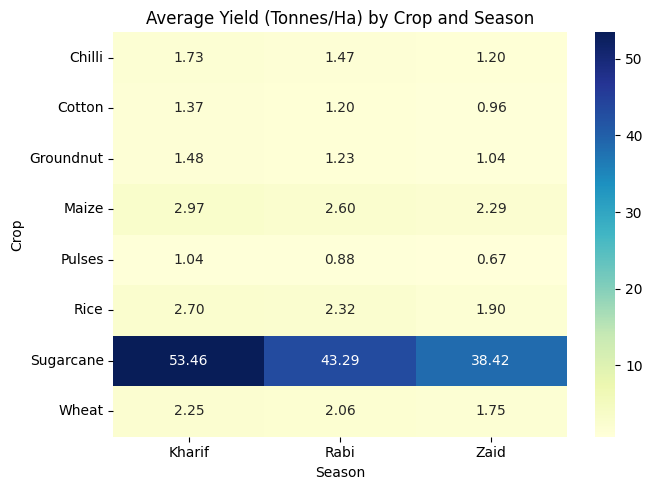

In [21]:
crop_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean').round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title("Average Yield (Tonnes/Ha) by Crop and Season")
plt.ylabel("Crop")
plt.xlabel("Season")
plt.tight_layout()
plt.show()


###  State-wise Seasonal Profit Comparison

In [22]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean').round(0)
state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


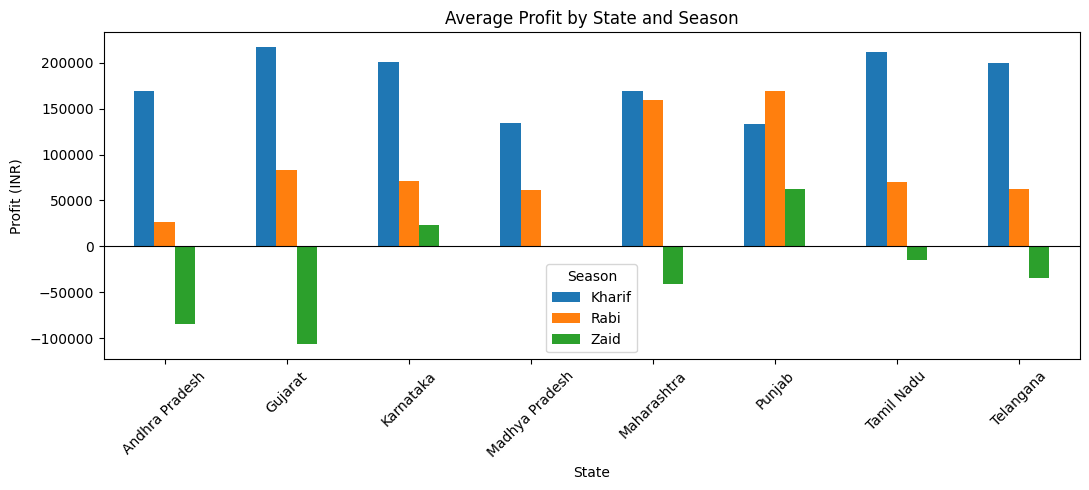

In [23]:
state_season_profit.plot(kind='bar', figsize=(11, 5))
plt.title("Average Profit by State and Season")
plt.ylabel("Profit (INR)")
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()


## 15. What Factors are Most Related to Yield?

We look at the correlation between yield and a few key numeric factors. A value close to 1 or -1 means a strong relationship; a value close to 0 means little to no relationship.

In [24]:
cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
        'Fertilizer_kg_ha', 'Water_Efficiency_t_per_1000m3', 'Yield_Tonnes_Ha']

correlation = df[cols].corr()['Yield_Tonnes_Ha'].sort_values(ascending=False)
print(correlation.round(2))


Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.91
Rainfall_mm                      0.03
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Fertilizer_kg_ha                 0.00
Name: Yield_Tonnes_Ha, dtype: float64


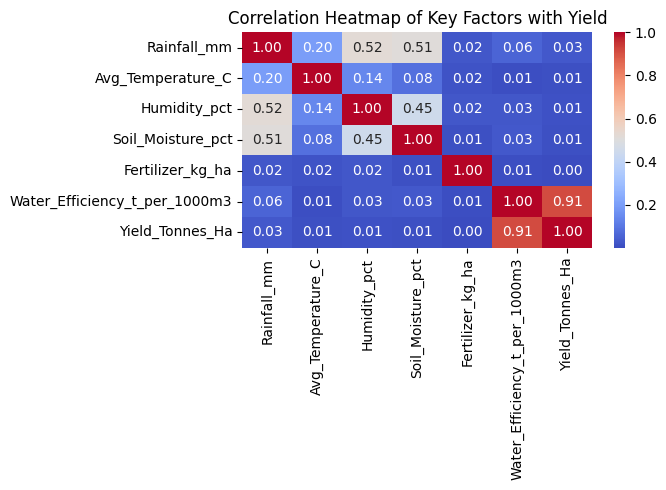

In [25]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Key Factors with Yield")
plt.tight_layout()
plt.show()


 Water efficiency has a very strong positive correlation with yield (~0.92), meaning farms that use water more efficiently consistently achieve higher yields. Rainfall, temperature, humidity, soil moisture and fertilizer use show almost no direct correlation with yield on their own — suggesting yield is driven more by how well water is used than by raw weather conditions.

### Key Insights

1. **Kharif performs the best overall** — highest average yield and highest average profit, supported by the highest rainfall and the best water efficiency of the three seasons.
2. **Zaid performs the weakest** — lowest yield, a net average loss, and the highest percentage of farms operating at a loss compared to Kharif and Rabi.
3. **Water efficiency matters more than rainfall alone** — it shows the strongest relationship with yield (correlation ≈ 0.92), far higher than rainfall, temperature, humidity, soil moisture or fertilizer use individually.
4. **Irrigation method has a clear effect on yield** — Drip irrigation consistently outperforms Sprinkler, Flood and Rainfed methods.
5. **Kharif's strength comes with a trade-off** — it also has the highest disease/pest risk, likely linked to higher rainfall and humidity, so it needs the most careful pest management despite being the top-performing season.
6. **Crop choice interacts with season** — Sugarcane and Chilli stay profitable across all seasons, while crops like Rice, Maize, Wheat and Pulses swing into loss specifically during Zaid.
7. **The seasonal pattern holds broadly across states** — Kharif's advantage and Zaid's weakness are not limited to one region, but appear consistently in the state-wise comparison.

### Recommendations

- **Prioritize Kharif-season cultivation** where feasible, given its consistently higher yield and profitability.
- **Re-evaluate crop selection for Zaid season** — crops that run at a loss in Zaid (e.g. Rice, Wheat, Maize) may need to be swapped for more resilient, consistently profitable crops such as Sugarcane or Chilli.
- **Invest in drip irrigation**, especially for farms currently using Rainfed or Flood methods, since irrigation method is one of the clearest, most consistent drivers of yield in the data.
- **Focus resource-efficiency efforts on water use specifically**, since water efficiency is the strongest single factor linked to yield — more impactful than rainfall, temperature or fertilizer alone.
- **Strengthen pest and disease management during Kharif**, to protect its otherwise strong yield and profit performance from its higher pest/disease risk.

### Conclusion

This analysis shows that agricultural performance varies meaningfully across seasons, with Kharif consistently outperforming Rabi and Zaid on yield and profitability, and Zaid consistently the weakest and riskiest season for farmers. Environmental conditions like rainfall and temperature set the backdrop for each season, but resource-use efficiency — particularly water efficiency and irrigation method — turns out to be the strongest determinant of yield, more so than weather alone. Crop choice also matters differently by season, with some crops holding steady profit year-round and others losing money specifically in Zaid. Together, these findings support season-aware crop planning and targeted investment in efficient irrigation as practical, evidence-based ways to improve agricultural outcomes.
